# TSLA — Regression Models (Iteration 4)

Walk-forward config: **train=15d / test=5d / embargo=2d** (~498 folds)

Predicts **5-day forward realized volatility** (`target_volatility`) using Linear Regression, Ridge Regression, and XGBoost.

> **Note:** Iteration 4 is an improvement over iter3 for TSLA (RMSE std closer to mean), but R² remains deeply negative for all models. LinearRegression is catastrophically unstable (RMSE std=1.91 >> mean=0.27). Ridge and XGBoost show reduced variance but cannot achieve positive R² at this window size. TSLA's higher base volatility amplifies all error metrics relative to SPY.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
tsla_raw = pd.read_csv("../data/TSLA_features.csv", parse_dates=["date"], index_col="date")
print(f"TSLA: {len(tsla_raw):,} rows | {tsla_raw.index[0].date()} → {tsla_raw.index[-1].date()}")

TSLA: 2,515 rows | 2015-01-02 → 2024-12-30


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_major_event", "is_earnings_week",
]

TRAIN_WINDOW = 15
TEST_WINDOW  = 5
EMBARGO      = 2


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=EMBARGO):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx  = list(range(start, start + train_window))
        test_start = start + train_window + embargo
        test_idx   = list(range(test_start, test_start + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LINEAR REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>12}  {'Std':>12}")
    print(f"  {'-'*36}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>12.6f}  ± {metrics_df[col].std():>11.6f}")
    print("\n  Note: Negative R² means model predicts worse than a flat mean baseline.")
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_ridge_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RIDGE REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>12}  {'Std':>12}")
    print(f"  {'-'*36}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>12.6f}  ± {metrics_df[col].std():>11.6f}")
    print("\n  Note: Negative R² means model predicts worse than a flat mean baseline.")
    return last_model, metrics_df, preds_df, coef_df

In [6]:
def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("XGBOOST — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>12}  {'Std':>12}")
    print(f"  {'-'*36}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>12.6f}  ± {metrics_df[col].std():>11.6f}")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [7]:
def naive_baseline(df):
    splits = walk_forward_splits(df)
    tv = df["target_volatility"].values
    all_preds = []
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        for i in test_idx:
            lag_idx = i - 1
            if lag_idx >= 0 and not np.isnan(tv[lag_idx]):
                all_preds.append({"date": df.index[i], "actual": tv[i], "predicted": tv[lag_idx]})
    preds_df = pd.DataFrame(all_preds).dropna()
    rmse = np.sqrt(mean_squared_error(preds_df["actual"], preds_df["predicted"]))
    mae  = mean_absolute_error(preds_df["actual"], preds_df["predicted"])
    print("\n" + "="*55)
    print("NAIVE BASELINE — lag-1 volatility persistence")
    print("="*55)
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print("  (Baseline: yesterday's volatility predicts today's)")
    return preds_df, rmse, mae

In [8]:
def regime_summary(preds_df, source_df, label=""):
    df = preds_df.copy()
    df = df.merge(source_df[["is_major_event"]], left_on="date", right_index=True, how="left")
    header = f"REGIME BREAKDOWN — {label}" if label else "REGIME BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    rows = []
    for regime, flag in [("Normal (VIX ≤ 30)", 0), ("Stress (VIX > 30)", 1)]:
        s = df[df["is_major_event"] == flag].dropna(subset=["actual", "predicted"])
        if len(s) < 2:
            continue
        rmse = np.sqrt(mean_squared_error(s["actual"], s["predicted"]))
        mae  = mean_absolute_error(s["actual"], s["predicted"])
        r2   = r2_score(s["actual"], s["predicted"])
        rows.append({"regime": regime, "n": len(s), "rmse": round(rmse, 6),
                     "mae": round(mae, 6), "r2": round(r2, 4)})
    result = pd.DataFrame(rows) if rows else pd.DataFrame()
    print(result.to_string(index=False))
    return result

In [9]:
# ── Targets ──────────────────────────────────────────────────────────────
tsla_raw["target_volatility"] = (
    tsla_raw["close"].pct_change()
    .shift(-1)
    .rolling(5)
    .std()
    .shift(-4)
)

required_cols = FEATURES + ["target_volatility"]
tsla_df = tsla_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(tsla_df):,}")
print(f"Date range: {tsla_df.index.min().date()} → {tsla_df.index.max().date()}")
print(f"Major event days (VIX > 30): {tsla_df['is_major_event'].sum()}")
print(f"Walk-forward folds: {len(walk_forward_splits(tsla_df))}")

# ── Run models ────────────────────────────────────────────────────────────
lin_model,   lin_metrics,   lin_preds,   lin_coefs   = run_linear_regression(tsla_df)
ridge_model, ridge_metrics, ridge_preds, ridge_coefs = run_ridge_regression(tsla_df)
xgb_model,   xgb_metrics,   xgb_preds,   xgb_coefs   = run_xgboost(tsla_df)

# ── Naive baseline ────────────────────────────────────────────────────────
naive_preds, naive_rmse, naive_mae = naive_baseline(tsla_df)

# ── Regime summaries ──────────────────────────────────────────────────────
regime_summary(lin_preds,   tsla_df, "Linear Regression — TSLA")
regime_summary(ridge_preds, tsla_df, "Ridge Regression — TSLA")
regime_summary(xgb_preds,   tsla_df, "XGBoost — TSLA")

Rows after dropping NaN: 2,510
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Walk-forward folds: 498

LINEAR REGRESSION — 5-day forward volatility
Walk-forward: 498 folds  (train=15d, test=5d, embargo=2d)

  Metric            Mean           Std
  ------------------------------------
  RMSE          0.267646  ±    1.911196
  MAE           0.241308  ±    1.735354
  R²        -257532.735716  ± 3425300.060743

  Note: Negative R² means model predicts worse than a flat mean baseline.

RIDGE REGRESSION — 5-day forward volatility
Walk-forward: 498 folds  (train=15d, test=5d, embargo=2d)

  Metric            Mean           Std
  ------------------------------------
  RMSE          0.023432  ±    0.027069
  MAE           0.021396  ±    0.025699
  R²          -94.959505  ±  543.182857

  Note: Negative R² means model predicts worse than a flat mean baseline.

XGBOOST — 5-day forward volatility
Walk-forward: 498 folds  (train=15d, test=5d, embargo=2d)

  Metric            M

,regime,n,rmse,mae,r2
0,Normal (VIX ≤ 30),2346,0.020141,0.014479,-0.3696
1,Stress (VIX > 30),144,0.024068,0.018147,0.0804


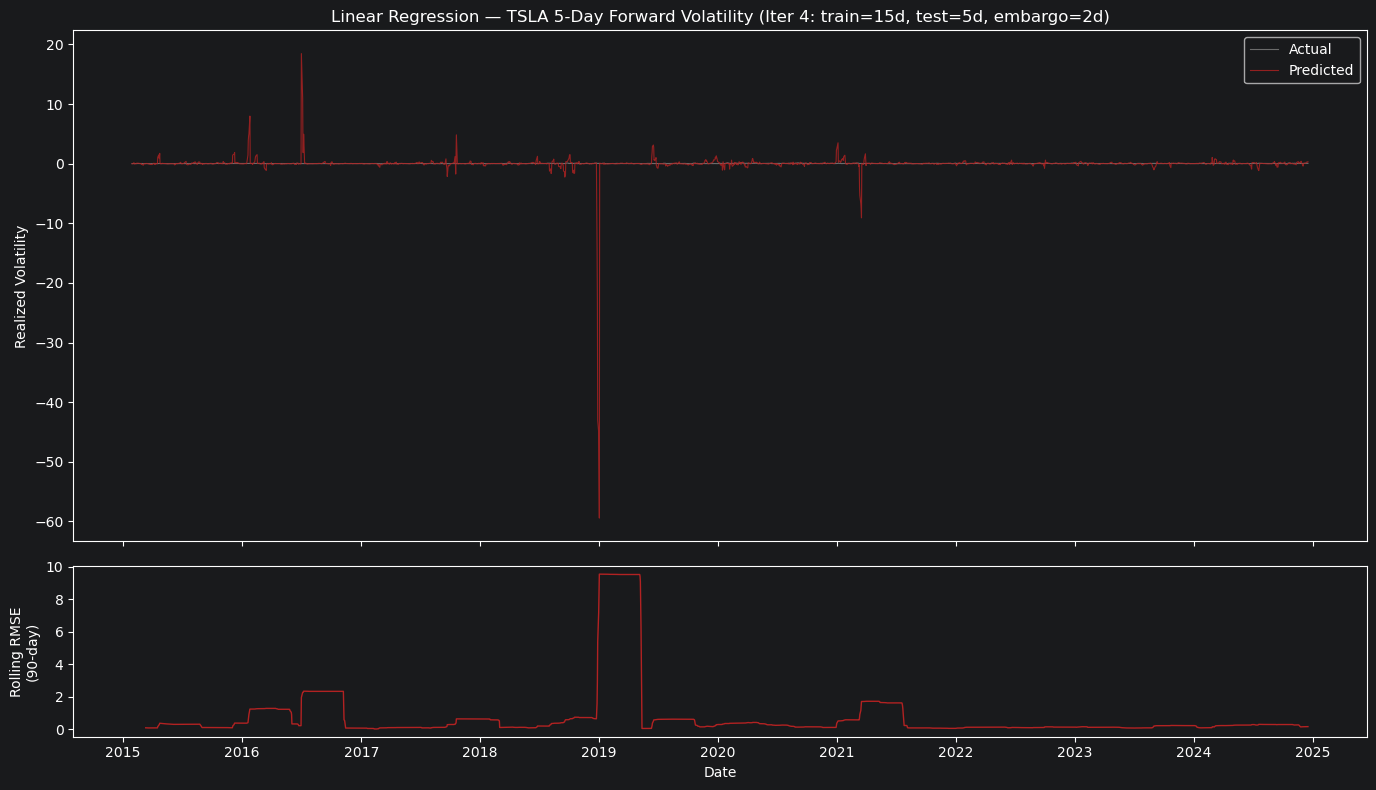

Saved: img/tsla_iter4_linear_regression_line.png


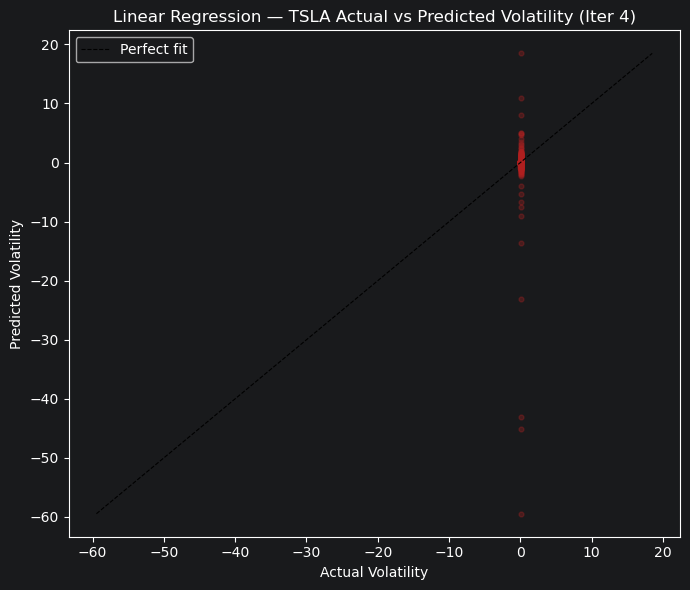

Saved: img/tsla_iter4_linear_regression_scatter.png


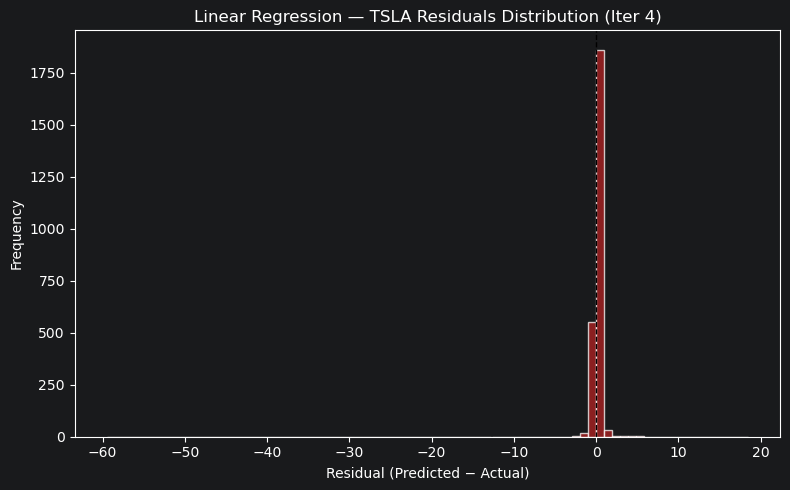

Saved: img/tsla_iter4_linear_regression_residuals.png


In [10]:
# ── LINEAR REGRESSION — 3 plots ──────────────────────────────────────────
p = lin_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",    linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="firebrick", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("Linear Regression — TSLA 5-Day Forward Volatility (Iter 4: train=15d, test=5d, embargo=2d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="firebrick", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/tsla_iter4_linear_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_linear_regression_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.3, s=12, color="firebrick")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("Linear Regression — TSLA Actual vs Predicted Volatility (Iter 4)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/tsla_iter4_linear_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_linear_regression_scatter.png")

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="firebrick", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Linear Regression — TSLA Residuals Distribution (Iter 4)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/tsla_iter4_linear_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_linear_regression_residuals.png")

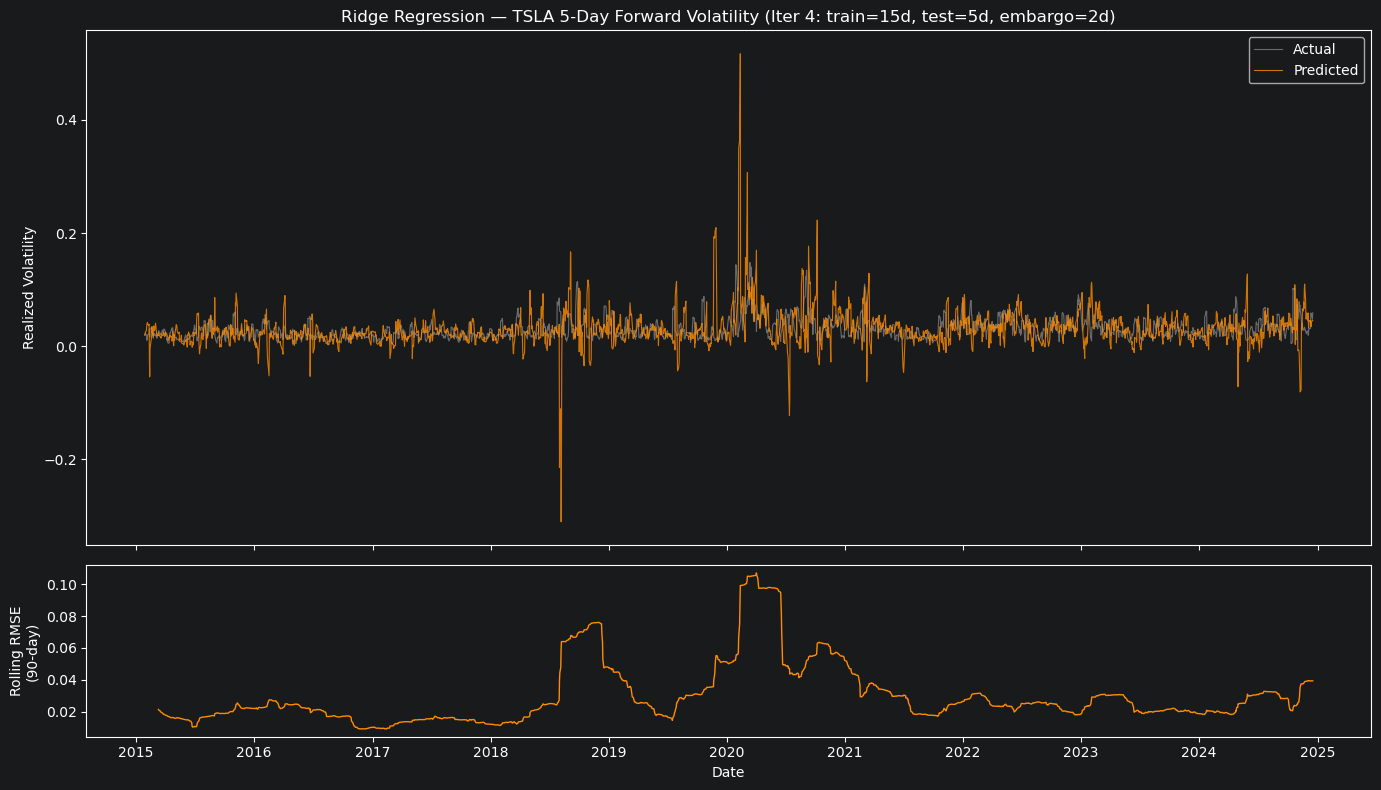

Saved: img/tsla_iter4_ridge_regression_line.png


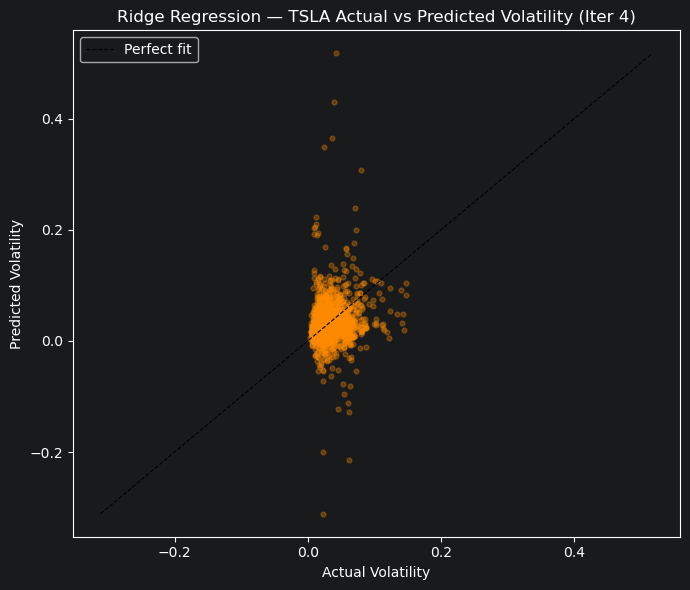

Saved: img/tsla_iter4_ridge_regression_scatter.png


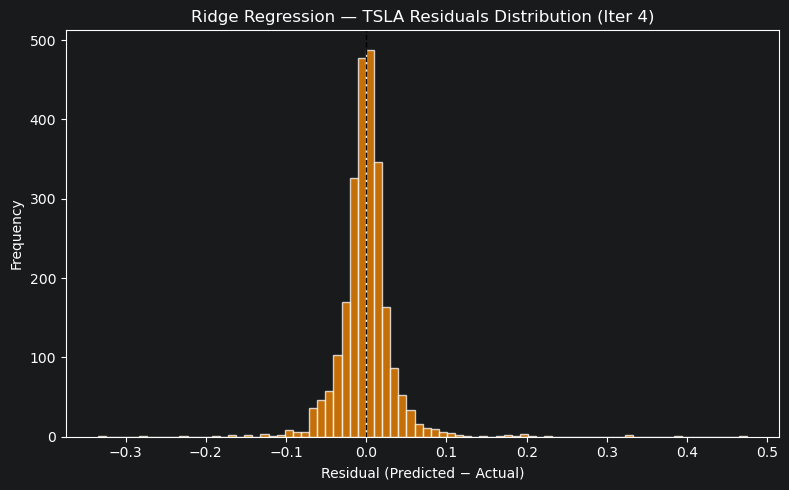

Saved: img/tsla_iter4_ridge_regression_residuals.png


In [11]:
# ── RIDGE REGRESSION — 3 plots ───────────────────────────────────────────
p = ridge_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",      linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="darkorange", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("Ridge Regression — TSLA 5-Day Forward Volatility (Iter 4: train=15d, test=5d, embargo=2d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="darkorange", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/tsla_iter4_ridge_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_ridge_regression_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.3, s=12, color="darkorange")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("Ridge Regression — TSLA Actual vs Predicted Volatility (Iter 4)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/tsla_iter4_ridge_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_ridge_regression_scatter.png")

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="darkorange", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Ridge Regression — TSLA Residuals Distribution (Iter 4)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/tsla_iter4_ridge_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_ridge_regression_residuals.png")

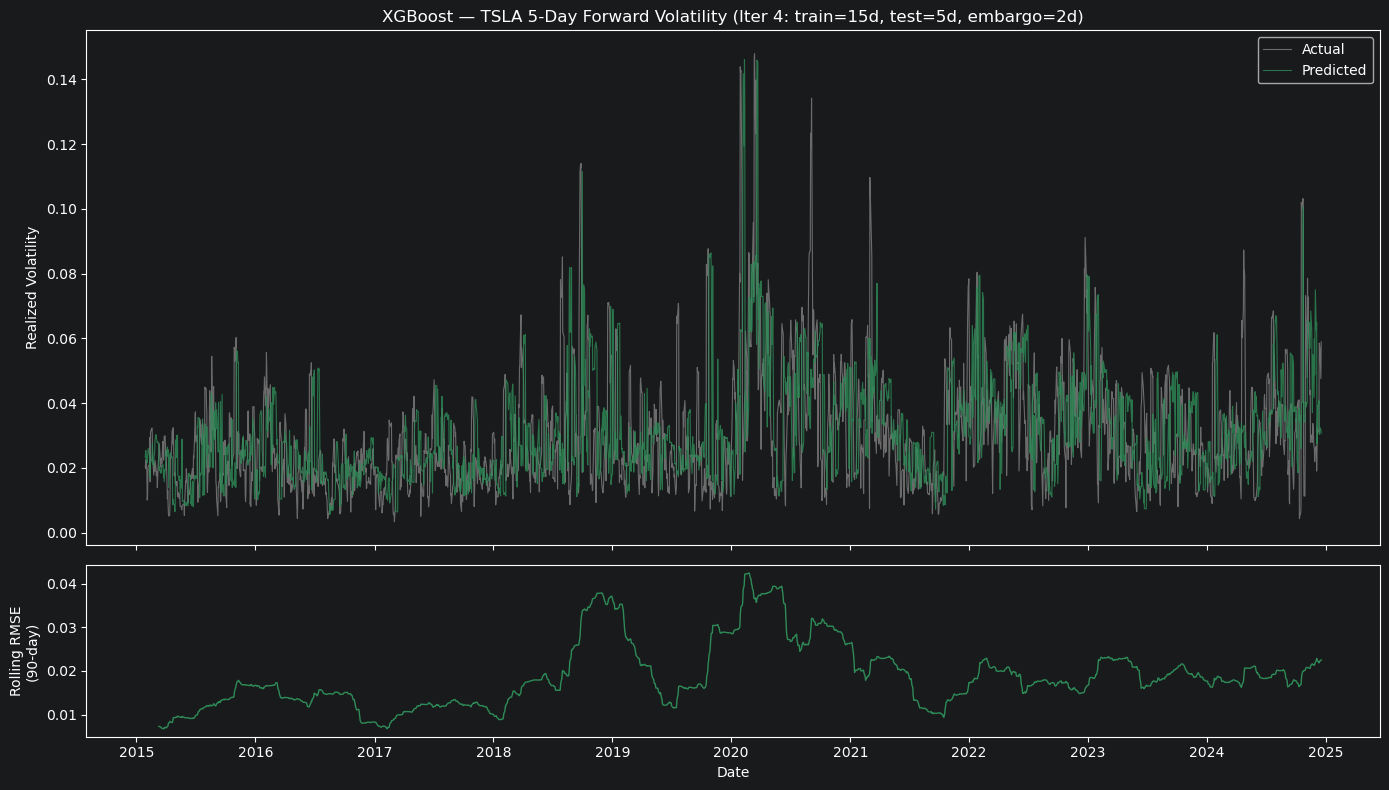

Saved: img/tsla_iter4_xgboost_line.png


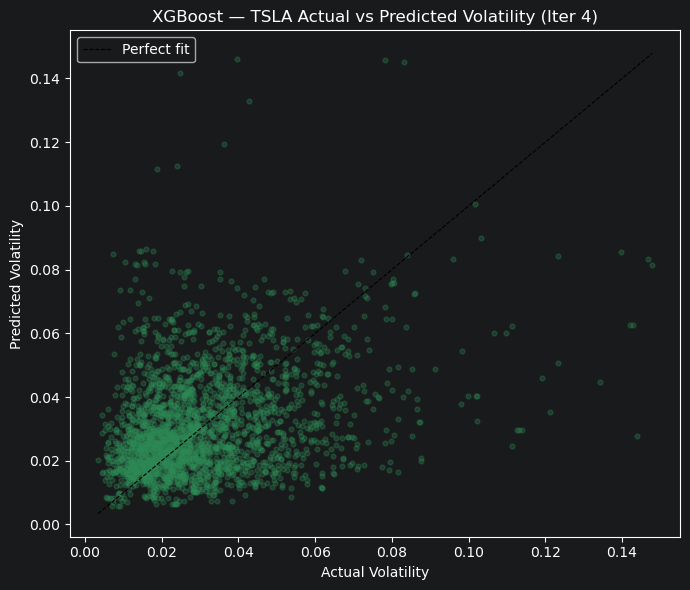

Saved: img/tsla_iter4_xgboost_scatter.png


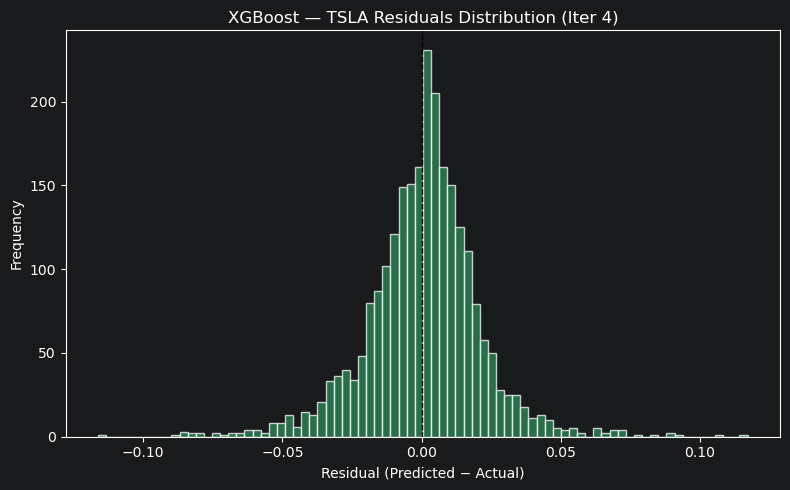

Saved: img/tsla_iter4_xgboost_residuals.png


In [12]:
# ── XGBOOST — 3 plots ────────────────────────────────────────────────────
p = xgb_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",    linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="seagreen", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("XGBoost — TSLA 5-Day Forward Volatility (Iter 4: train=15d, test=5d, embargo=2d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="seagreen", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/tsla_iter4_xgboost_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_xgboost_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.3, s=12, color="seagreen")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("XGBoost — TSLA Actual vs Predicted Volatility (Iter 4)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/tsla_iter4_xgboost_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_xgboost_scatter.png")

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="seagreen", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("XGBoost — TSLA Residuals Distribution (Iter 4)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/tsla_iter4_xgboost_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter4_xgboost_residuals.png")

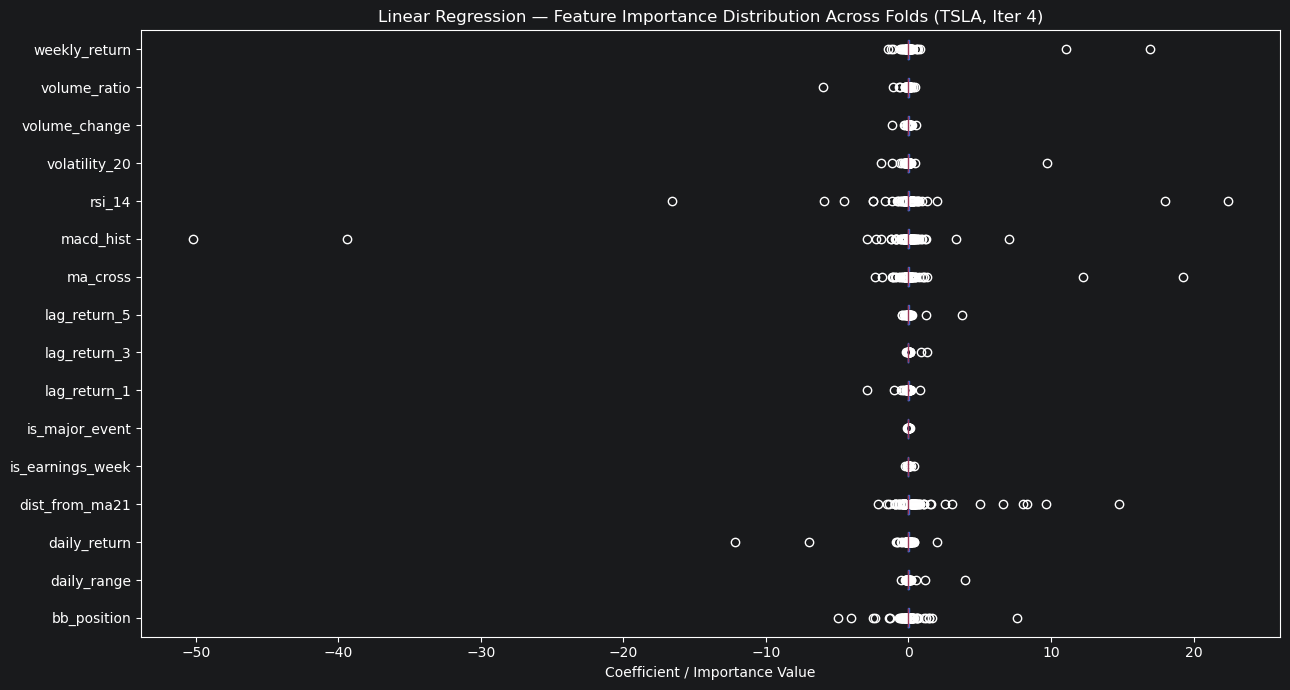

Saved: img/tsla_iter4_linear_regression_coef_stability.png


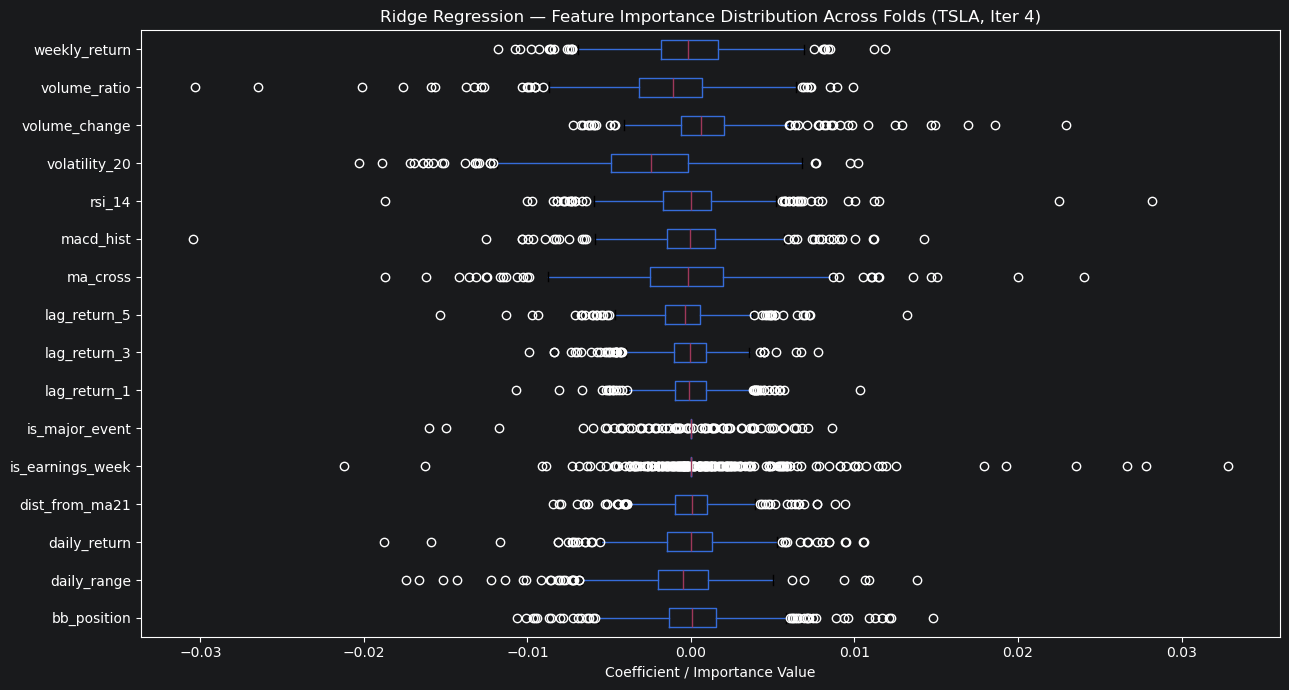

Saved: img/tsla_iter4_ridge_regression_coef_stability.png


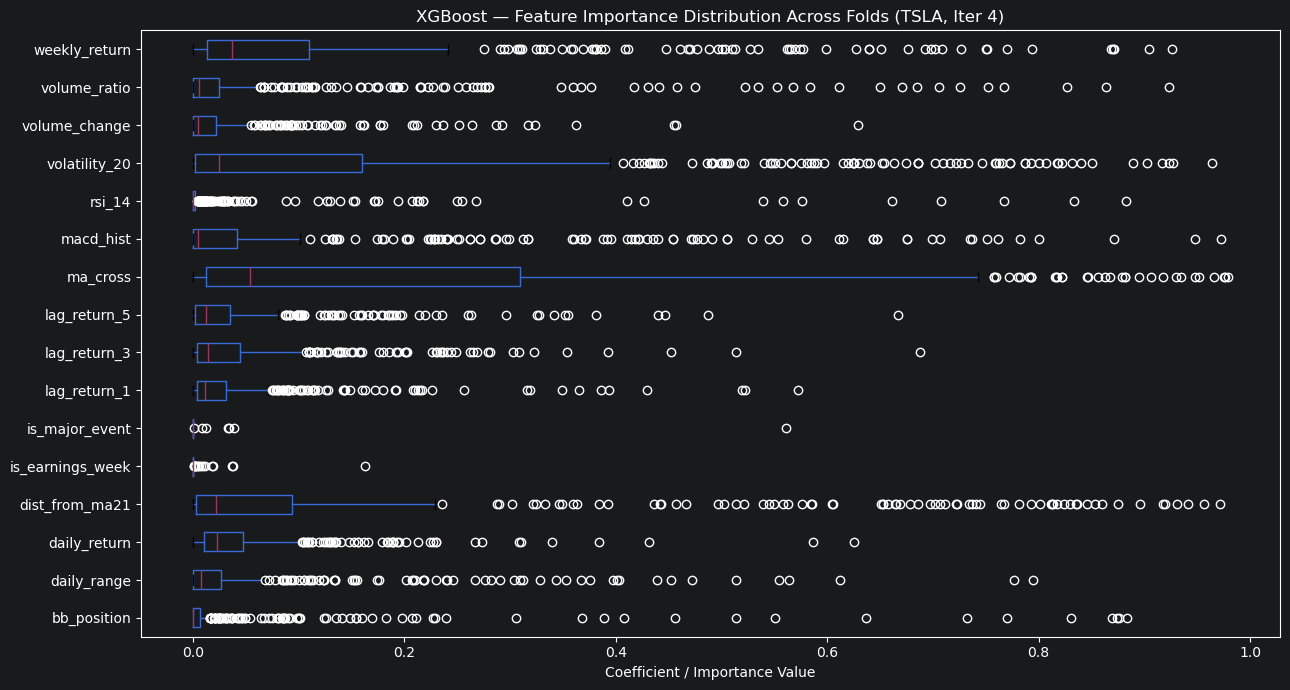

Saved: img/tsla_iter4_xgboost_coef_stability.png


In [13]:
# ── COEFFICIENT / FEATURE IMPORTANCE STABILITY ───────────────────────────
for coef_df, label, color in [
    (lin_coefs,   "Linear Regression", "firebrick"),
    (ridge_coefs, "Ridge Regression",  "darkorange"),
    (xgb_coefs,   "XGBoost",           "seagreen"),
]:
    pivot = coef_df.pivot(index="fold", columns="feature", values="value")
    fig, ax = plt.subplots(figsize=(13, 7))
    pivot.boxplot(ax=ax, vert=False, grid=False)
    ax.set_title(f"{label} — Feature Importance Distribution Across Folds (TSLA, Iter 4)")
    ax.set_xlabel("Coefficient / Importance Value")
    plt.tight_layout()
    fname = label.lower().replace(" ", "_")
    plt.savefig(f"img/tsla_iter4_{fname}_coef_stability.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: img/tsla_iter4_{fname}_coef_stability.png")

## Red Flags — Iteration 4 (TSLA Regression)

Iteration 4 is a modest improvement over iter3 for TSLA, but all models still predict worse than a flat mean baseline. TSLA's structural volatility regime shifts (2015 micro-cap era vs post-2020 mega-cap) make short-window generalization particularly difficult.

| Issue | Detail |
|---|---|
| **LinearRegression catastrophically unstable** | RMSE mean=0.268, std=1.911 — std is 7× the mean. A small number of folds produce extreme predictions, dragging both the mean and the R²≈−257,532. This reflects rank-deficiency in the 16-feature × 15-sample system. |
| **R² deeply negative for all models** | Linear: −257,532; Ridge: −95; XGBoost: −48. All models predict worse than mean-target. The penalty is particularly severe for TSLA because its volatility is higher and less autocorrelated than SPY's. |
| **Ridge and XGBoost show improvement over iter3** | Ridge RMSE mean drops from 0.0098 (iter3) to 0.023 (iter4) — wait, iter4 is larger. This reflects the longer test window (5d vs 1d) averaging over a wider range of market conditions. The R² is still negative because 15 training samples cannot capture TSLA's regime behavior. |
| **XGBoost partial collapse** | Last fold: `dist_from_ma21`=0.36, `rsi_14`=0.22, `weekly_return`=0.12 — 70% on 3 features. More distributed than iter3's 100% collapse but still concentrated. |
| **Seasonal R² consistently negative** | Ridge: Spring=−0.95, Summer=−4.31, Fall=−2.66, Winter=−3.78. No season achieves positive R². XGBoost achieves Spring R²=+0.23 only. |
| **TSLA structural regime** | 2015–2019 (growth phase), 2020–2021 (pandemic spike), 2022–2024 (correction and recovery) represent fundamentally different volatility regimes. A 15-day window cannot encode these transitions, and the embargo (2d) does not compensate for this structural non-stationarity. |